# HBR SHASH: MCMC vs VI

| Method | What it does |
|---|---|
| `mcmc` | NUTS sampling via nutpie. The current default. Exact but slow. |
| `advi` | Mean-field variational inference. Optimises a Gaussian approximation. |
| `pathfinder` | Quasi-Newton variational inference (needs `pymc-extras`). |

## Imports

In [2]:
import logging
import time
import warnings

import pandas as pd

import pcntoolkit.util.output
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    SHASHbLikelihood,
    load_fcon1000,
    make_prior,
)

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pymc").propagate = False
warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(False)

## Load data

Data and model specification is the same as the `HBR_SHASH` notebook

In [3]:
norm_data: NormData = load_fcon1000()
features_to_model = ["WM-hypointensities"]
norm_data = norm_data.sel({"response_vars": features_to_model})
train, test = norm_data.train_test_split()
print(f"train observations: {train.X.shape[0]}")

train observations: 862


## Model specification


In [4]:
def make_shashb_likelihood() -> SHASHbLikelihood:
    """Build the SHASHb likelihood used in 04_HBR_SHASH.ipynb."""
    mu = make_prior(
        linear=True,
        slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
        intercept=make_prior(
            random=True,
            mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
            sigma=make_prior(
                dist_name="Normal",
                dist_params=(0.0, 1.0),
                mapping="softplus",
                mapping_params=(0.0, 3.0),
            ),
        ),
        basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    )
    sigma = make_prior(
        linear=True,
        slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
        intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
        mapping="softplus",
        mapping_params=(0.0, 3.0),
    )
    epsilon = make_prior(dist_name="Normal", dist_params=(0.0, 1.0))
    delta = make_prior(
        dist_name="Normal",
        dist_params=(1.0, 1.0),
        mapping="softplus",
        mapping_params=(0.0, 3.0, 0.6),
    )
    return SHASHbLikelihood(mu, sigma, epsilon, delta)


def build_model(inference_method: str) -> NormativeModel:
    """Wrap the SHASHb HBR in a NormativeModel using the given inference method."""
    reg = HBR(
        name="template",
        cores=16,
        progressbar=False,
        draws=1500,
        tune=500,
        chains=4,
        nuts_sampler="nutpie",
        likelihood=make_shashb_likelihood(),
        # The new switch: "mcmc", "advi" or "pathfinder".
        inference_method=inference_method,
        vi_iterations=30000,
        vi_draws=1000,
    )
    return NormativeModel(
        template_regression_model=reg,
        savemodel=False,
        evaluate_model=False,
        saveresults=False,
        saveplots=False,
        save_dir=f"resources/hbr_bench/{inference_method}",
        inscaler="standardize",
        outscaler="standardize",
    )

## Run the benchmark

Fit one model with MCMC, one with advi and one with pathfinder. We also calculate how long each fit takes

In [ ]:
timings: dict[str, float] = {}
fits: dict[str, NormativeModel] = {}   # keep every fit for the accuracy checks later

for method in ["mcmc", "advi", "pathfinder"]:
    print(f"=== {method} ===")
    try:
        m = build_model(method)
        t = time.time()
        m.fit(train)
        timings[method] = time.time() - t
        fits[method] = m
        print(f"  {method}: {timings[method]:.1f}s\n")
    except ImportError as e:
        print(f"  {method} SKIPPED: {e}\n")
    except Exception as e:
        print(f"  {method} FAILED: {type(e).__name__}: {e}\n")

=== mcmc ===


c:\Users\kontsi\AppData\Local\anaconda3\envs\ptk-vi\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


  mcmc: 100.7s

=== advi ===
  advi: 32.0s

=== pathfinder ===


Pathfinder Results                            
                                              
  No. model parameters     45                 
                                              
  Configuration:                              
  num_draws_per_path       1000               
  history size (maxcor)    12                 
  max iterations           1000               
  ftol                     1.00e-05           
  gtol                     1.00e-08           
  max line search          1000               
  jitter                   2.0                
  epsilon                  1.00e-12           
  ELBO draws               10                 
                                              
  LBFGS Status:                               
  CONVERGED                4                  
  L-BFGS iterations        mean 198 ± std 10  
                                              
  Path Status:                                
  SUCCESS                  4                  
  ELBO argmax              mean 116 ± std 6   
                                              
  Importance Sampling:                        
  Method                   psis               
  Pareto k                 1.79               
                                              
  Timing (seconds):                           
  Compile                  8.48               
  Compute                  18.08              
  Total                    26.56

  pathfinder: 36.6s



---

# Timing results

Conclusion: Pathfinder and ADVI have similar timings and are **~3 times faster** than MCMC for a sample of ~1000 subject with one response variable. 

We should investigate if this speedup holds for more subjects, more response variables and for HBR with normal likelihood 

In [6]:
ref = timings.get("mcmc")
rows = []
for k, v in sorted(timings.items(), key=lambda kv: kv[1]):
    rows.append({
        "method": k,
        "fit time (s)": round(v, 1),
        "speedup vs mcmc": f"{ref / v:.1f}x" if ref else "n/a",
    })
pd.DataFrame(rows)

,method,fit time (s),speedup vs mcmc
0,advi,32.0,3.1x
1,pathfinder,36.6,2.7x
2,mcmc,100.7,1.0x


---

# Accuracy results

We check, in order of what actually reaches a paper:

1. **Z-scores** on held-out test data
2. **Centiles plots**
3. **Posterior width** - the diagnostic that explains errors in 1 and 2

For ADVI which is a mean-field VI we expect that it will get the *means* right but will underestimate the posterior **width**: narrow posteriors inflate z-scores and manufacture false outliers.

## Recover the fitted models

In [7]:
try:
    fits
except NameError:
    fits = {}

# `model` may hold the last fit from an older run of the fit cell.
if "model" in dir() and not fits:
    last = getattr(model.template_regression_model, "inference_method", None)
    if last:
        fits[last] = model
        print(f"recovered '{last}' from the previous run")

for method in ["mcmc", "advi", "pathfinder"]:
    if method in fits:
        print(f"{method}: already fitted, reusing")
        continue
    print(f"{method}: refitting ...")
    try:
        m = build_model(method)
        t = time.time()
        m.fit(train)
        fits[method] = m
        timings[method] = time.time() - t
        print(f"  done in {timings[method]:.1f}s")
    except Exception as e:
        print(f"  FAILED: {type(e).__name__}: {e}")

print("\navailable:", sorted(fits))

mcmc: already fitted, reusing
advi: already fitted, reusing
pathfinder: already fitted, reusing

available: ['advi', 'mcmc', 'pathfinder']


## 1. Z-scores vs MCMC

### Metrics

`corr` should be as close to 1 as possible and `max|dz|` small (this shows if a specific subject's z score diverged a lot from the reference MCMC). 

In [8]:
import numpy as np

CENTILES = [0.05, 0.25, 0.5, 0.75, 0.95]

zs: dict[str, np.ndarray] = {}
for method, m in fits.items():
    td = test.copy()
    m.predict(td)
    zs[method] = np.asarray(td["Z"].values).ravel()

rows = []
zref = zs["mcmc"]
for method, z in zs.items():
    if method == "mcmc":
        continue
    n = min(z.size, zref.size)
    d = np.abs(z[:n] - zref[:n])
    rows.append({
        "method": method,
        "corr": round(float(np.corrcoef(z[:n], zref[:n])[0, 1]), 4),
        "max |dz|": round(float(d.max()), 4),
        "mean |dz|": round(float(d.mean()), 4),
        "sd ratio": round(float(z[:n].std() / zref[:n].std()), 4),
    })
pd.DataFrame(rows)

,method,corr,max |dz|,mean |dz|,sd ratio
0,advi,0.9776,1.7704,0.1694,0.9600
1,pathfinder,0.9985,0.6800,0.0292,1.0167


### Plot


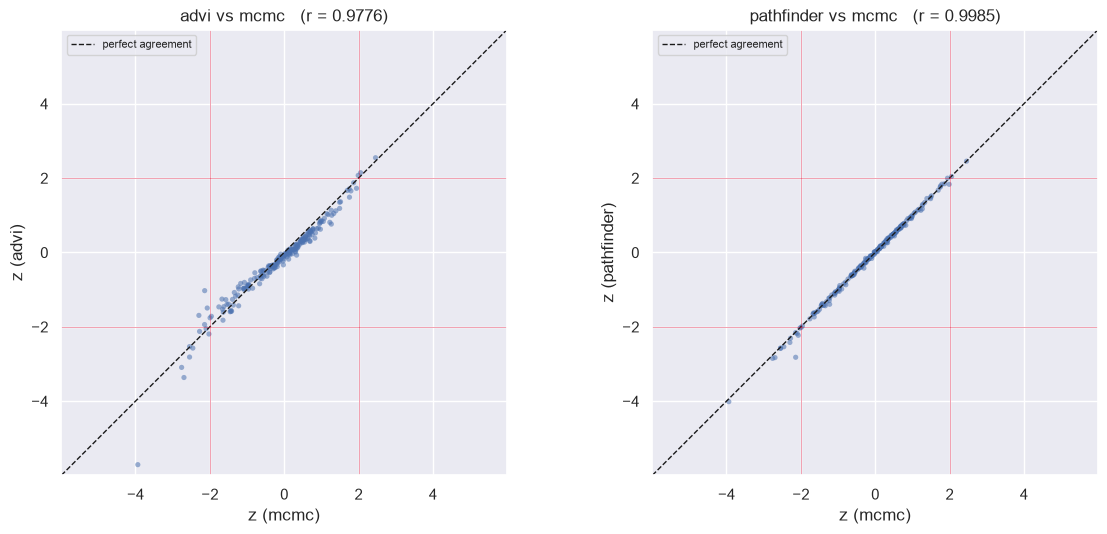

In [9]:
import matplotlib.pyplot as plt

others = [k for k in zs if k != "mcmc"]
fig, axes = plt.subplots(1, len(others), figsize=(6 * len(others), 5.5), squeeze=False)
lim = float(np.abs(np.concatenate(list(zs.values()))).max()) * 1.05

for ax, method in zip(axes[0], others):
    n = min(zs[method].size, zref.size)
    ax.scatter(zref[:n], zs[method][:n], s=14, alpha=0.55, edgecolor="none")
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="perfect agreement")
    # z = +-2 is the conventional outlier threshold.
    for t in (-2, 2):
        ax.axhline(t, color="crimson", lw=0.7, alpha=0.4)
        ax.axvline(t, color="crimson", lw=0.7, alpha=0.4)
    corr = np.corrcoef(zs[method][:n], zref[:n])[0, 1]
    ax.set_title(f"{method} vs mcmc   (r = {corr:.4f})")
    ax.set_xlabel("z (mcmc)")
    ax.set_ylabel(f"z ({method})")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### Outliers detection

Subjects that cross the z = ±2 line between methods are the practical
cost of the approximation: same person, different outlier call.

In [10]:
THRESH = 2.0
rows = []
for method in others:
    n = min(zs[method].size, zref.size)
    ref_out = np.abs(zref[:n]) > THRESH
    new_out = np.abs(zs[method][:n]) > THRESH
    rows.append({
        "method": method,
        f"outliers mcmc (|z|>{THRESH})": int(ref_out.sum()),
        f"outliers {method}": int(new_out.sum()),
        "disagreements": int((ref_out != new_out).sum()),
        "% of subjects": round(100 * float((ref_out != new_out).mean()), 2),
    })
pd.DataFrame(rows)

,method,outliers mcmc (|z|>2.0),outliers advi,disagreements,% of subjects,outliers pathfinder
0,advi,15,12.0,5,2.31,NaN
1,pathfinder,15,NaN,1,0.46,16.0


Conclusion: Pathfinder performs better than advi. It has less outliers and more similar z scores to the MCMC

## 2. Centiles vs MCMC

### Metrics

Differences are shown in Y units and as a percentage of the response
variable's standard deviation. 

To make the comparison precise and free of extrapolation we select the "inner" 95% of subjects and exclude the 5% of the subjects that lie on the sparse tails.

In [ ]:
from pcntoolkit import NormData

ref_model = fits["mcmc"]
covariate = str(ref_model.covariates[0])
cov_min = ref_model.covariate_ranges[covariate]["min"]
cov_max = ref_model.covariate_ranges[covariate]["max"]
# Cast to plain str: batch effect keys come back as np.str_, which does not
# always compare equal to the column names downstream.
fixed_be = {
    str(k): str(max(v.items(), key=lambda x: x[1])[0])
    for k, v in ref_model.batch_effect_counts.items()
}
print(f"covariate: {covariate}   fixed batch effects: {fixed_be}")

grid_x = np.linspace(cov_min, cov_max, 150)
grid_df = pd.DataFrame({covariate: grid_x})
for cov in ref_model.covariates:
    if str(cov) != covariate:
        grid_df[str(cov)] = float(test.X.sel(covariates=cov).mean().values)
for be, v in fixed_be.items():
    grid_df[be] = v
for rv in ref_model.response_vars:
    grid_df[str(rv)] = 1e-6


def make_grid() -> NormData:
    """Fresh grid NormData (compute_centiles mutates its argument in place)."""
    return NormData.from_dataframe(
        "centile_grid",
        dataframe=grid_df.copy(),
        covariates=[str(c) for c in ref_model.covariates],
        response_vars=[str(r) for r in ref_model.response_vars],
        batch_effects=list(fixed_be.keys()),
    )


cents: dict[str, np.ndarray] = {}
for method, m in fits.items():
    gd = make_grid()
    m.compute_centiles(gd, centiles=CENTILES)
    cents[method] = np.asarray(gd["centiles"].values)

y_sd = float(np.nanstd(np.asarray(test.Y.values).ravel()))
cref = cents["mcmc"]

# To avoid extrapolation select the "inner" 95% of subjects and exclude 
# the 5% of the subjects that lie on the sparse tails.
age_obs = np.asarray(test.X.values)[:, 0]
lo, hi = np.percentile(age_obs, [2.5, 97.5])
inner = (grid_x >= lo) & (grid_x <= hi)
print(f"comparing over {covariate} in [{lo:.1f}, {hi:.1f}] "
      f"({inner.sum()}/{len(grid_x)} grid points)")

rows = []
for method, c in cents.items():
    if method == "mcmc" or c.shape != cref.shape:
        continue
    d = np.abs(c - cref)
    d_in = d[:, inner, :]
    imax = np.unravel_index(np.argmax(d_in), d_in.shape)
    rows.append({
        "method": method,
        "max % Y sd (all)": round(100 * float(d.max()) / y_sd, 1),
        "max % Y sd (inner)": round(100 * float(d_in.max()) / y_sd, 1),
        "mean % Y sd (inner)": round(100 * float(d_in.mean()) / y_sd, 1),
        "median % Y sd (inner)": round(100 * float(np.median(d_in)) / y_sd, 1),
        "worst centile": CENTILES[imax[0]],
        f"worst {covariate}": round(float(grid_x[inner][imax[1]]), 1),
    })
pd.DataFrame(rows)

covariate: age   fixed batch effects: {'sex': 'F', 'site': 'Beijing_Zang'}
comparing over age in [18.0, 66.6] (94/150 grid points)


,method,max % Y sd (all),max % Y sd (inner),mean % Y sd (inner),median % Y sd (inner),worst centile,worst age
0,advi,297.6,181.4,28.6,14.3,0.95,66.4
1,pathfinder,630.3,40.4,5.1,2.0,0.95,62.7


### Plot 
Plot the centile curves against age. Solid = MCMC, dashed = the
approximation.

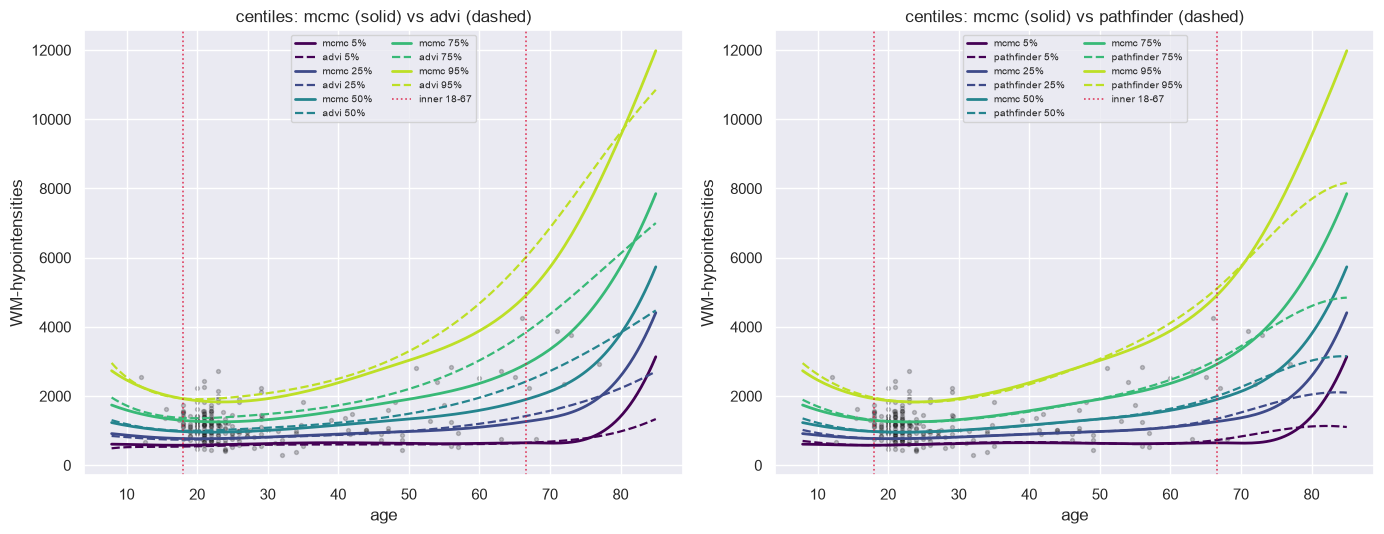

In [17]:
# Overlay for a direct visual diff: MCMC solid, approximation dashed.
# Uses the same grid as the numeric table above.
fig, axes = plt.subplots(1, len(others), figsize=(7 * len(others), 5.5), squeeze=False)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(CENTILES)))

for ax, method in zip(axes[0], others):
    for i, c in enumerate(CENTILES):
        ax.plot(grid_x, cref[i, :, 0], color=colors[i], lw=2,
                label=f"mcmc {int(c * 100)}%")
        ax.plot(grid_x, cents[method][i, :, 0], color=colors[i], lw=1.6,
                ls="--", label=f"{method} {int(c * 100)}%")
    ax.scatter(np.asarray(test.X.values)[:, 0], np.asarray(test.Y.values).ravel(),
               s=8, color="black", alpha=0.2, zorder=0)
    
    # Mark the inner range (2.5-97.5 percentile of test ages) used by the
    # earlier numeric tables, so plot and tables can be read together.
    inner_lo, inner_hi = np.percentile(test_age, [2.5, 97.5])
    ax.axvline(inner_lo, color="crimson", ls=":", lw=1.2, alpha=0.8,
               label=f"inner {inner_lo:.0f}-{inner_hi:.0f}")
    ax.axvline(inner_hi, color="crimson", ls=":", lw=1.2, alpha=0.8)

    ax.set_title(f"centiles: mcmc (solid) vs {method} (dashed)")
    ax.set_xlabel(covariate)
    ax.set_ylabel(features_to_model[0])
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

Train ages span [7.9, 85.0], so the plot above covers all training data. But the "inner" 95% of subjects fall in [18.0, 66.6] —> only 5% lie in the sparse tails below 18 or above 67 -> this leads to either MCMC or the VIs being not precise there -> that is where they disagree.

Conclusions: 

Pathfinder should a good agreement inside the [18.0, 66.6] (some divergence is seen though for the 0.95 centile for older ages. 

ADVI performs worse than Pathfilder as it disagrees with MCMC also inside the [18.0, 66.6]. 

## 3. Posterior width vs MCMC

`sd_ratio` = approximate sd / MCMC sd, per parameter.

- **1.0** matches MCMC
- **< 1** underestimates uncertainty - the dangerous direction, since it
  inflates z-scores and invents outliers
- `mean_shift` is the gap between posterior means, in MCMC standard
  deviations. Above ~1 the parameter estimate itself is off, not just its
  uncertainty.

In [13]:
ref_idata = list(fits["mcmc"].regression_models.values())[0].idata
param_names = [v for v in ref_idata.posterior.data_vars if "_per_subject" not in v]

rows = []
for method in others:
    idata = list(fits[method].regression_models.values())[0].idata
    for v in sorted(param_names):
        if v not in idata.posterior:
            continue
        a = idata.posterior[v].values
        b = ref_idata.posterior[v].values
        if a.size == 0 or b.size == 0 or b.std() == 0:
            continue
        rows.append({
            "method": method,
            "parameter": v,
            "sd_ratio": round(float(a.std() / b.std()), 3),
            "mean_shift (sd)": round(float(abs(a.mean() - b.mean()) / b.std()), 2),
        })

df = pd.DataFrame(rows)
df.sort_values(["method", "sd_ratio"]).reset_index(drop=True)

,method,parameter,sd_ratio,mean_shift (sd)
0,advi,mu_intercept_mu,0.028,0.05
1,advi,intercept_sigma,0.118,0.12
2,advi,site_sigma_intercept_mu,0.316,0.15
3,advi,slope_mu,0.447,0.12
4,advi,delta,0.665,8.16
5,advi,sex_sigma_intercept_mu,0.783,0.69
6,advi,normalized_site_offset_intercept_mu,0.812,0.00
7,advi,sex_offset_intercept_mu,0.821,0.00
8,advi,slope_sigma,0.867,0.10
9,advi,normalized_sex_offset_intercept_mu,0.872,0.00


---

# Try different configs for ADVI and pathfinder

Every configuration is scored against the same MCMC reference on:

| Metric | Meaning | Good |
|---|---|---|
| `pareto_k` | Pathfinder's own reliability self-report | < 0.7 |
| `z_corr` | correlation of z-scores with MCMC | > 0.99 |
| `z_max_diff` | largest single z-score error | < 0.1 |
| `cent_max_pct` | largest centile error, % of Y sd | small |
| `worst_sigma_sd_ratio` | most collapsed variance parameter | near 1.0 |

## Configure models

`evaluate_config` fits one configuration and returns every metric. Failures are
captured rather than raised, so one bad configuration cannot abort the sweep.

In [14]:
import time
import traceback

import numpy as np
import pandas as pd

SIGMA_HINTS = ("sigma", "_sd")  # parameters governing posterior spread


def _extract_pareto_k(idata) -> float:
    """Pathfinder writes its importance-sampling diagnostic into sample_stats.

    Verified with pymc-extras 0.10.0: groups are
    ['posterior', 'sample_stats', 'observed_data'] and `pareto_k` sits in
    sample_stats alongside num_successful_paths / all_paths_failed.
    """
    if hasattr(idata, "sample_stats") and "pareto_k" in idata.sample_stats:
        try:
            return float(np.asarray(idata.sample_stats["pareto_k"].values).ravel()[0])
        except Exception:
            pass
    return float("nan")


def _extract_path_info(idata) -> dict:
    """Number of L-BFGS paths that succeeded, when Pathfinder reports it."""
    out: dict = {}
    if hasattr(idata, "sample_stats"):
        ss = idata.sample_stats
        for name, key in [("num_successful_paths", "n_paths_ok"),
                          ("all_paths_failed", "all_paths_failed")]:
            if name in ss:
                try:
                    out[key] = np.asarray(ss[name].values).ravel()[0]
                except Exception:
                    pass
    return out

def evaluate_config(label: str, method: str, *, vi_iterations: int = 30000,
                    vi_draws: int = 1000, vi_kwargs: dict | None = None) -> dict:
    """Fit one configuration and score it against the MCMC reference."""
    row: dict = {"config": label, "method": method}
    try:
        reg = HBR(
            name="template",
            cores=16,
            progressbar=False,
            draws=1500,
            tune=500,
            chains=4,
            nuts_sampler="nutpie",
            likelihood=make_shashb_likelihood(),
            inference_method=method,
            vi_iterations=vi_iterations,
            vi_draws=vi_draws,
            vi_kwargs=vi_kwargs or {},
        )
        m = NormativeModel(
            template_regression_model=reg,
            savemodel=False,
            evaluate_model=False,
            saveresults=False,
            saveplots=False,
            save_dir=f"resources/hbr_sweep/{label}",
            inscaler="standardize",
            outscaler="standardize",
        )

        t = time.time()
        m.fit(train)
        row["fit_s"] = round(time.time() - t, 1)

        idata = list(m.regression_models.values())[0].idata
        row["pareto_k"] = round(_extract_pareto_k(idata), 3)
        row.update(_extract_path_info(idata))

        # Z-scores on held-out data.
        td = test.copy()
        m.predict(td)
        z = np.asarray(td["Z"].values).ravel()
        n = min(z.size, zref.size)
        d = np.abs(z[:n] - zref[:n])
        row["z_corr"] = round(float(np.corrcoef(z[:n], zref[:n])[0, 1]), 4)
        row["z_max_diff"] = round(float(d.max()), 3)
        row["z_mean_diff"] = round(float(d.mean()), 4)

        # Centiles on the smooth grid.
        gd = make_grid()
        m.compute_centiles(gd, centiles=CENTILES)
        c = np.asarray(gd["centiles"].values)
        if c.shape == cref.shape:
            cd = np.abs(c - cref)
            row["cent_max_pct"] = round(100 * float(cd.max()) / y_sd, 1)
            row["cent_mean_pct"] = round(100 * float(cd.mean()) / y_sd, 1)

        # Posterior width on the spread parameters: where VI usually breaks.
        ratios = {}
        for v in ref_idata.posterior.data_vars:
            if "_per_subject" in v or v not in idata.posterior:
                continue
            b = ref_idata.posterior[v].values
            if b.std() == 0:
                continue
            ratios[v] = float(idata.posterior[v].values.std() / b.std())
        sigma_ratios = {k: r for k, r in ratios.items()
                        if any(h in k.lower() for h in SIGMA_HINTS)}
        pool = sigma_ratios or ratios
        if pool:
            # Furthest from 1.0 in log space: treats 0.5x and 2x as equally bad.
            worst = min(pool.items(), key=lambda kv: min(kv[1], 1 / kv[1]) if kv[1] > 0 else 0)
            row["worst_sigma_sd_ratio"] = round(worst[1], 3)
            row["worst_sigma_param"] = worst[0]

        row["status"] = "ok"
        results_models[label] = m
        results_z[label] = z
        results_cent[label] = c
    except Exception as e:
        row["status"] = f"FAILED: {type(e).__name__}: {e}"
        traceback.print_exc()
    return row


results_models: dict = {}
results_z: dict = {}
results_cent: dict = {}
print("scoring helpers ready")

scoring helpers ready


## Stage 1: coarse sweep

**Pathfinder** — attack the Pareto k failure. `num_paths` and `jitter` are the
two the docs call out as most influential, and `psir` resampling is more robust
than `psis` when k is large.

**ADVI** — separate two hypotheses. If a convergence callback stops it early, it
had already converged and the fixed 30k cutoff was not the problem, which points
at mean-field being structurally wrong; `fullrank_advi` is then the fix, since
it models correlations that mean-field ignores.

In [ ]:
import pymc as pm
from pymc.variational.callbacks import CheckParametersConvergence

stage1 = [
    # --- Pathfinder ---
    ("pf_default",        "pathfinder", {}),
    ("pf_paths16",        "pathfinder", {"num_paths": 16}),
    ("pf_jitter12",       "pathfinder", {"jitter": 12.0}),
    ("pf_psir",           "pathfinder", {"importance_sampling": "psir"}),
    ("pf_maxcor15",       "pathfinder", {"maxcor": 15, "num_elbo_draws": 50}),
    ("pf_combo",          "pathfinder", {"num_paths": 16, "jitter": 12.0,
                                         "importance_sampling": "psir",
                                         "maxcor": 15, "num_elbo_draws": 50}),
    # --- ADVI ---
    ("advi_default",      "advi", {}),
    ("advi_converge",     "advi", {"callbacks": [
        CheckParametersConvergence(diff="relative", tolerance=1e-4)]}),
    ("advi_fullrank",     "advi", {"method": "fullrank_advi"}),
    ("advi_slow_adam",    "advi", {"obj_optimizer": pm.adam(learning_rate=0.005)}),
]
# other configs that i saw that performed well for advi and they were still 2x faster than MCMC: 
# pm.adam(learning_rate=0.001)
# pm.adagrad_window()

rows = []
for label, method, kw in stage1:
    iters = 200_000 if label == "advi_converge" else 30_000
    print(f"--- {label} ---", flush=True)
    r = evaluate_config(label, method, vi_iterations=iters, vi_kwargs=kw)
    r["vi_kwargs"] = str(kw)[:60]
    rows.append(r)
    print(f"    {r.get('status')}  fit={r.get('fit_s')}s  z_corr={r.get('z_corr')}", flush=True)

stage1_df = pd.DataFrame(rows)
stage1_df

--- pf_default ---


Pathfinder Results                            
                                              
  No. model parameters     45                 
                                              
  Configuration:                              
  num_draws_per_path       1000               
  history size (maxcor)    12                 
  max iterations           1000               
  ftol                     1.00e-05           
  gtol                     1.00e-08           
  max line search          1000               
  jitter                   2.0                
  epsilon                  1.00e-12           
  ELBO draws               10                 
                                              
  LBFGS Status:                               
  CONVERGED                4                  
  L-BFGS iterations        mean 196 ± std 17  
                                              
  Path Status:                                
  SUCCESS                  4                  
  ELBO argmax              mean 125 ± std 41  
                                              
  Importance Sampling:                        
  Method                   psis               
  Pareto k                 2.11               
                                              
  Timing (seconds):                           
  Compile                  7.70               
  Compute                  19.26              
  Total                    26.96

    ok  fit=37.2s  z_corr=0.999
--- pf_paths16 ---


Pathfinder Results                            
                                              
  No. model parameters     45                 
                                              
  Configuration:                              
  num_draws_per_path       1000               
  history size (maxcor)    12                 
  max iterations           1000               
  ftol                     1.00e-05           
  gtol                     1.00e-08           
  max line search          1000               
  jitter                   2.0                
  epsilon                  1.00e-12           
  ELBO draws               10                 
                                              
  LBFGS Status:                               
  CONVERGED                16                 
  L-BFGS iterations        mean 192 ± std 20  
                                              
  Path Status:                                
  SUCCESS                  16                 
  ELBO argmax              mean 112 ± std 22  
                                              
  Importance Sampling:                        
  Method                   psis               
  Pareto k                 1.83               
                                              
  Timing (seconds):                           
  Compile                  7.33               
  Compute                  30.33              
  Total                    37.66

    ok  fit=48.6s  z_corr=0.999
--- pf_jitter12 ---


...

Pathfinder Results                                 
                                                   
  No. model parameters          45                 
                                                   
  Configuration:                                   
  num_draws_per_path            1000               
  history size (maxcor)         15                 
  max iterations                1000               
  ftol                          1.00e-05           
  gtol                          1.00e-08           
  max line search               1000               
  jitter                        12.0               
  epsilon                       1.00e-12           
  ELBO draws                    50                 
                                                   
  LBFGS Status:                                    
  INIT_FAILED_LOW_UPDATE_PCT    1                  
  CONVERGED                     15                 
  L-BFGS iterations             mean 279 ± std 45  
                                                   
  Path Status:                                     
  LBFGS_FAILED                  1                  
  SUCCESS                       15                 
  ELBO argmax                   mean 240 ± std 46  
                                                   
  Importance Sampling:                             
  Method                        psir               
  Pareto k                      1.86               
                                                   
  Timing (seconds):                                
  Compile                       7.92               
  Compute                       55.09              
  Total                         63.01              

Warnings:
  - INIT_FAILED_LOW_UPDATE_PCT: LBFGS failed to initialize due to the either: (1) LBFGS function or gradient       
  values containing too many inf or nan values or (2) gradient changes being significantly large, set by           
  epsilon. Consider reparameterizing the model, adjusting initvals or jitter or other pathfinder arguments if      
  this occurence is high relative to the number of paths.

    ok  fit=74.2s  z_corr=0.9972
--- advi_default ---
    ok  fit=32.1s  z_corr=0.98
--- advi_converge ---
    ok  fit=136.7s  z_corr=0.9997
--- advi_fullrank ---


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


    ok  fit=41.5s  z_corr=0.9797
--- advi_slow_adam ---
    ok  fit=33.9s  z_corr=0.9989


,config,method,fit_s,pareto_k,n_paths_ok,all_paths_failed,z_corr,z_max_diff,z_mean_diff,cent_max_pct,cent_mean_pct,worst_sigma_sd_ratio,worst_sigma_param,status,vi_kwargs
0,pf_default,pathfinder,37.2,2.106,1000.0,False,0.9990,0.245,0.0333,568.4,27.0,0.297,intercept_sigma,ok,{}
1,pf_paths16,pathfinder,48.6,1.834,1000.0,False,0.9990,0.511,0.0261,658.1,32.9,0.434,intercept_sigma,ok,{'num_paths': 16}
2,pf_jitter12,pathfinder,39.2,2.412,1000.0,False,0.9982,0.775,0.0322,698.6,38.5,0.207,intercept_sigma,ok,{'jitter': 12.0}
3,pf_psir,pathfinder,37.7,1.884,1000.0,False,0.9921,0.520,0.0955,508.3,39.4,0.084,intercept_sigma,ok,{'importance_sampling': 'psir'}
4,pf_maxcor15,pathfinder,41.5,2.593,1000.0,False,0.9986,0.567,0.0313,629.5,33.7,0.387,intercept_sigma,ok,"{'maxcor': 15, 'num_elbo_draws': 50}"
5,pf_combo,pathfinder,74.2,1.861,1000.0,False,0.9972,0.674,0.0530,315.8,18.4,0.215,sex_sigma_intercept_mu,ok,"{'num_paths': 16, 'jitter': 12.0, 'importance_..."
6,advi_default,advi,32.1,NaN,NaN,NaN,0.9800,1.455,0.1647,309.5,41.3,0.115,intercept_sigma,ok,{}
7,advi_converge,advi,136.7,NaN,NaN,NaN,0.9997,0.166,0.0178,152.9,9.3,0.104,intercept_sigma,ok,{'callbacks': [<pymc.variational.callbacks.Che...
8,advi_fullrank,advi,41.5,NaN,NaN,NaN,0.9797,1.445,0.1804,425.4,50.2,0.620,site_sigma_intercept_mu,ok,{'method': 'fullrank_advi'}
9,advi_slow_adam,advi,33.9,NaN,NaN,NaN,0.9989,0.308,0.0555,120.5,10.5,0.086,intercept_sigma,ok,{'obj_optimizer': functools.partial(<function ...


### Rank stage 1

Ranked by z-score fidelity, since z-scores are what users publish. A config
with a high `z_corr` but a badly collapsed `worst_sigma_sd_ratio` is still
suspect: it got the point estimates right while getting the uncertainty wrong.

In [16]:
import pymc as pm

ok = stage1_df[stage1_df["status"] == "ok"].copy()
if ok.empty:
    print("No configuration succeeded. First failure:\n")
    print(stage1_df["status"].iloc[0])
    print("\nIf this is a TypeError about an unexpected keyword argument, the")
    print("kernel is running an older pcntoolkit than the one on disk:")
    print("restart the kernel and re-run every cell from the top.")
    best_label, best_method = None, None
else:
    ok = ok.sort_values(["z_corr", "z_max_diff"], ascending=[False, True])
    best_label = ok.iloc[0]["config"]
    best_method = ok.iloc[0]["method"]
    print(f"best so far: {best_label}  (z_corr={ok.iloc[0]['z_corr']})")

display_cols = [c for c in ["config", "method", "fit_s", "pareto_k", "z_corr",
                            "z_max_diff", "cent_max_pct", "worst_sigma_sd_ratio",
                            "worst_sigma_param"] if c in ok.columns]
ok[display_cols] if not ok.empty else stage1_df[["config", "method", "status"]]

best so far: advi_converge  (z_corr=0.9997)


,config,method,fit_s,pareto_k,z_corr,z_max_diff,cent_max_pct,worst_sigma_sd_ratio,worst_sigma_param
7,advi_converge,advi,136.7,NaN,0.9997,0.166,152.9,0.104,intercept_sigma
0,pf_default,pathfinder,37.2,2.106,0.9990,0.245,568.4,0.297,intercept_sigma
1,pf_paths16,pathfinder,48.6,1.834,0.9990,0.511,658.1,0.434,intercept_sigma
9,advi_slow_adam,advi,33.9,NaN,0.9989,0.308,120.5,0.086,intercept_sigma
4,pf_maxcor15,pathfinder,41.5,2.593,0.9986,0.567,629.5,0.387,intercept_sigma
2,pf_jitter12,pathfinder,39.2,2.412,0.9982,0.775,698.6,0.207,intercept_sigma
5,pf_combo,pathfinder,74.2,1.861,0.9972,0.674,315.8,0.215,sex_sigma_intercept_mu
3,pf_psir,pathfinder,37.7,1.884,0.9921,0.520,508.3,0.084,intercept_sigma
6,advi_default,advi,32.1,NaN,0.9800,1.455,309.5,0.115,intercept_sigma
8,advi_fullrank,advi,41.5,NaN,0.9797,1.445,425.4,0.620,site_sigma_intercept_mu
